In [1]:
import sys
from pathlib import Path
sys.path.append("/home/ethantu/workspace/good-vibrations/src3")

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from io_utils import load
from vibrations_pipeline import _extract_signal, _normalize_fft

In [88]:
EXPERIMENT_DIR  = Path('/home/ethantu/workspace/good-vibrations/experiment-20/data')
BASE_SAMPLE_DIR = EXPERIMENT_DIR / 'samples'
SAMPLE_IDS = list(range(40))
SAMPLE_DIRS = [BASE_SAMPLE_DIR / f"{i:06d}" for i in range(72)]

sample_dir = SAMPLE_DIRS[0]
sample_dir

PosixPath('/home/ethantu/workspace/good-vibrations/experiment-20/data/samples/000000')

In [ ]:
def load_fft(sample_dir):
    fft, freqs = load(sample_dir / 'inputs/03_fft_shifts.npz', keys=['fft', 'freqs'])
    metadata = {k: v for d in load(sample_dir / "metadata.jsonl") for k, v in d.items()}
    com = metadata['com']
    speaker = int(metadata['sample_id']) % 8  # proxy for speaker since it wasn't recorded
    fft = fft.squeeze(0)                               # (1, L, F, C) -> (L, F, C)
    X_raw = _extract_signal(fft, 'magnitude')          # (L, F, C)
    X_norm = _normalize_fft(X_raw[None], 'std-sample').squeeze(0)  # (L, F, C)
    return X_raw, X_norm, freqs, speaker, com

In [63]:
results = [load_fft(d) for d in SAMPLE_DIRS[:8]]

# sanity checks
coms = [r[4] for r in results]
assert all(c == coms[0] for c in coms), f"Samples have different centers of mass: {coms}"

freqs_list = [r[2] for r in results]
for i, f in enumerate(freqs_list):
    print(f"Sample {i}: freqs shape={f.shape}, min={f.min():.1f}, max={f.max():.1f}")

Sample 0: freqs shape=(2946,), min=50.0, max=1000.0
Sample 1: freqs shape=(3421,), min=50.0, max=1000.0
Sample 2: freqs shape=(3421,), min=50.0, max=1000.0
Sample 3: freqs shape=(3421,), min=50.0, max=1000.0
Sample 4: freqs shape=(3421,), min=50.0, max=1000.0
Sample 5: freqs shape=(3421,), min=50.0, max=1000.0
Sample 6: freqs shape=(3421,), min=50.0, max=1000.0
Sample 7: freqs shape=(3421,), min=50.0, max=1000.0


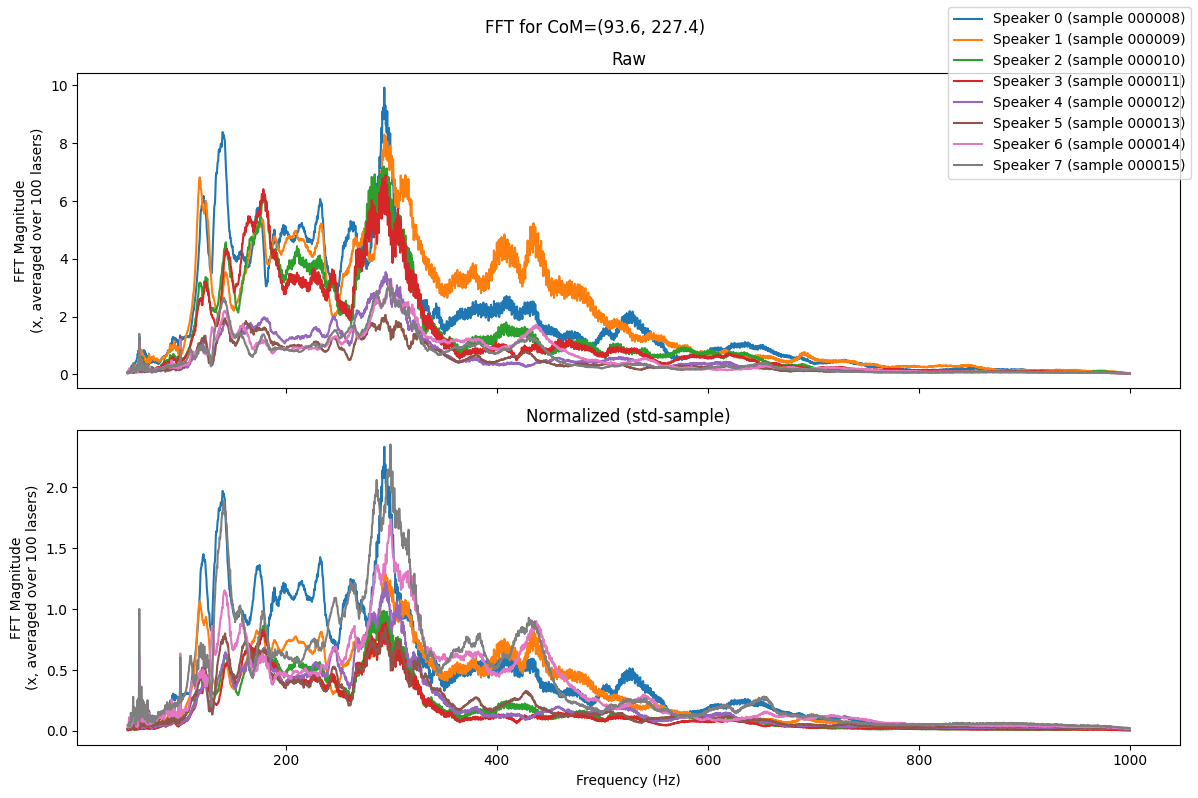

In [74]:
def reduce(X, laser_idx, xy_idx):
    # X: (L, F, C)
    l = slice(None) if laser_idx is None else laser_idx
    c = slice(None) if xy_idx is None else xy_idx
    return X[l, :, c].mean(axis=(0, -1)) if laser_idx is None and xy_idx is None \
        else X[l, :, c].mean(axis=0) if laser_idx is None \
        else X[l, :, c].mean(axis=-1) if xy_idx is None \
        else X[l, :, c]  # scalar laser + xy: shape (F,)

def _ylabel(laser_idx, xy_idx):
    xy_names = {0: 'x', 1: 'y'}
    parts = []
    if xy_idx is not None:
        parts.append(xy_names.get(xy_idx, str(xy_idx)))
    if laser_idx is not None:
        parts.append(f'laser {laser_idx}')
    if laser_idx is None:
        parts.append('averaged over 100 lasers')
    if xy_idx is None:
        parts.append('averaged over x,y')
    return 'FFT Magnitude\n(' + ', '.join(parts) + ')'

def plot_fft(sample_dirs, laser_idx=None, xy_idx=None):
    results = [load_fft(d) for d in sample_dirs]

    coms = [r[4] for r in results]
    assert all(c == coms[0] for c in coms), f"Samples have different centers of mass: {coms}"
    freqs_list = [r[2] for r in results]
    assert all(np.array_equal(f, freqs_list[0]) for f in freqs_list), "Samples have different frequency axes"
    com = coms[0]

    ylabel = _ylabel(laser_idx, xy_idx)
    colors = plt.cm.tab10.colors
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"FFT for CoM=({com[0]:.1f}, {com[1]:.1f})")

    for (X_raw, X_norm, freqs, speaker, _), d in zip(results, sample_dirs):
        label = f"Speaker {speaker} (sample {d.name})"
        ax1.plot(freqs, reduce(X_raw, laser_idx, xy_idx), color=colors[speaker], label=label)
        ax2.plot(freqs, reduce(X_norm, laser_idx, xy_idx), color=colors[speaker], label=label)

    ax1.set(ylabel=ylabel, title='Raw')
    ax2.set(ylabel=ylabel, xlabel='Frequency (Hz)', title='Normalized (std-sample)')
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right')
    plt.tight_layout()
    plt.show()

plot_fft(SAMPLE_DIRS[8:16], xy_idx=0)

In [ ]:
for d in SAMPLE_DIRS[:16]:
    shape = load(d / 'inputs/00_raw_vibrations.npy').shape
    print(f"{d.name}: {shape}")

shapes = [load(d / 'inputs/00_raw_vibrations.npy').shape for d in SAMPLE_DIRS[:16]]
assert len(set(shapes)) == 1, f"Shapes differ: {shapes}"
print("All same shape:", shapes[0])

000000: (7750, 300, 1056)
000001: (9000, 300, 1056)
000002: (9000, 300, 1056)
000003: (9000, 300, 1056)
000004: (9000, 300, 1056)
000005: (9000, 300, 1056)
000006: (9000, 300, 1056)
000007: (9000, 300, 1056)
000008: (9000, 300, 1056)
000009: (9000, 300, 1056)
000010: (9000, 300, 1056)
000011: (9000, 300, 1056)
000012: (9000, 300, 1056)
000013: (9000, 300, 1056)
000014: (9000, 300, 1056)
000015: (9000, 300, 1056)
All same shape: (9000, 300, 1056)


# Dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE
import umap

# load all samples — skip those with mismatched freq axis
sample_dirs = SAMPLE_DIRS[8:56]
all_results = [load_fft(d) for d in sample_dirs]
ref_freqs = all_results[0][2]
all_results = [(X_raw, X_norm, freqs, speaker, com, d)
               for (X_raw, X_norm, freqs, speaker, com), d in zip(all_results, sample_dirs)
               if np.array_equal(freqs, ref_freqs)]

print(f"{len(all_results)} samples loaded")

X_matrix = np.stack([X_norm.mean(axis=(0, 2)) for X_raw, X_norm, freqs, speaker, com, d in all_results])
speakers  = [speaker for *_, speaker, com, d in all_results]
positions = [str(com) for *_, speaker, com, d in all_results]
coms      = [com for *_, speaker, com, d in all_results]
names     = [d.name for *_, d in all_results]

pcs  = PCA(n_components=3).fit_transform(X_matrix)
lle  = LocallyLinearEmbedding(n_components=3, n_neighbors=10).fit_transform(X_matrix)
tsne = TSNE(n_components=3, perplexity=5, random_state=42).fit_transform(X_matrix)
ump  = umap.UMAP(n_components=3, n_neighbors=10, random_state=42).fit_transform(X_matrix)

print(f"PCA: {pcs.shape}, LLE: {lle.shape}, t-SNE: {tsne.shape}, UMAP: {ump.shape}")

48 samples loaded


/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


PCA: (48, 3), LLE: (48, 3), t-SNE: (48, 3), UMAP: (48, 3)


In [104]:
import plotly.graph_objects as go
import colorsys

def hsl_to_hex(h, s, l):
    r, g, b = colorsys.hls_to_rgb(h / 360, l / 100, s / 100)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

def plot_embedding_3d(embedding, title='3D Embedding'):
    unique_positions = sorted(set(positions))
    valid_markers = ['circle', 'square', 'diamond', 'cross', 'x', 'circle-open', 'square-open', 'diamond-open']
    pos_to_marker = {p: valid_markers[i % len(valid_markers)] for i, p in enumerate(unique_positions)}

    n_speakers = 8
    spk_to_color = {s: hsl_to_hex(int(360 * s / n_speakers), 70, 50) for s in range(n_speakers)}

    traces = {}
    for pt, speaker, pos, com, name in zip(embedding, speakers, positions, coms, names):
        key = (speaker, pos)
        if key not in traces:
            traces[key] = dict(x=[], y=[], z=[], text=[], marker_symbol=pos_to_marker[pos],
                               color=spk_to_color[speaker], speaker=speaker)
        traces[key]['x'].append(pt[0])
        traces[key]['y'].append(pt[1])
        traces[key]['z'].append(pt[2])
        traces[key]['text'].append(f"sample {name}<br>speaker {speaker}<br>COM ({com[0]:.1f}, {com[1]:.1f})")

    data_traces = [
        go.Scatter3d(x=t['x'], y=t['y'], z=t['z'], text=t['text'], mode='markers',
                     hovertemplate='%{text}<extra></extra>',
                     showlegend=False, legendgroup=f"spk_{t['speaker']}",
                     marker=dict(size=8, symbol=t['marker_symbol'], color=t['color'], line=dict(width=1, color='black')))
        for t in traces.values()
    ]
    spk_legend = [
        go.Scatter3d(x=[None], y=[None], z=[None], mode='markers',
                     name=f'Speaker {s}', legendgroup=f'spk_{s}',
                     legendgrouptitle=dict(text='Speaker') if i == 0 else {},
                     marker=dict(size=8, symbol='circle', color=spk_to_color[s]))
        for i, s in enumerate(range(n_speakers))
    ]
    pos_legend = [
        go.Scatter3d(x=[None], y=[None], z=[None], mode='markers',
                     name=f'COM {p}', legendgroup='position',
                     legendgrouptitle=dict(text='Position') if i == 0 else {},
                     marker=dict(size=8, symbol=pos_to_marker[p], color='grey', line=dict(width=1, color='black')))
        for i, p in enumerate(unique_positions)
    ]
    fig = go.Figure(data_traces + spk_legend + pos_legend)
    fig.update_layout(title=title, width=1400, height=800,
                      scene=dict(xaxis_title='Dim 1', yaxis_title='Dim 2', zaxis_title='Dim 3'),
                      legend=dict(groupclick='togglegroup'))
    fig.show()

for emb, name in [(pcs, 'PCA'), (lle, 'LLE'), (tsne, 't-SNE'), (ump, 'UMAP')]:
    plot_embedding_3d(emb, title=f'{name} of normalized FFT magnitudes (samples 8–55)')

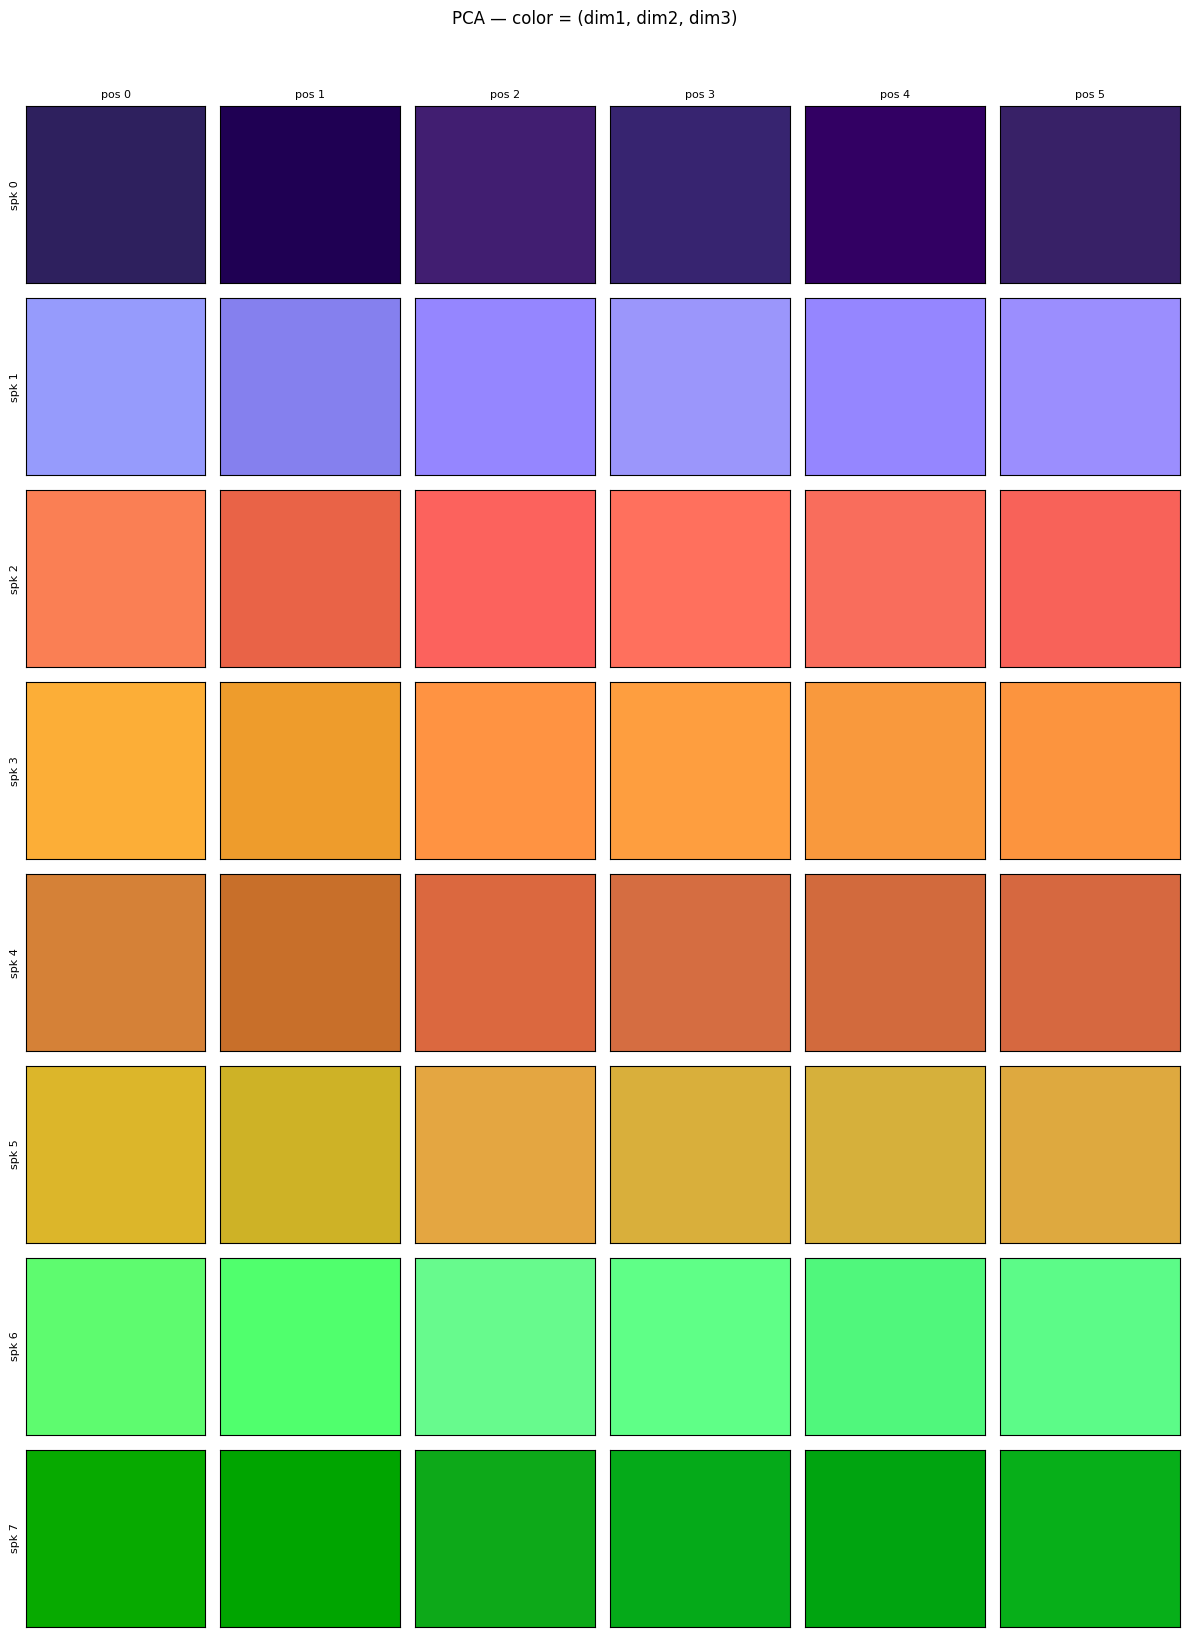

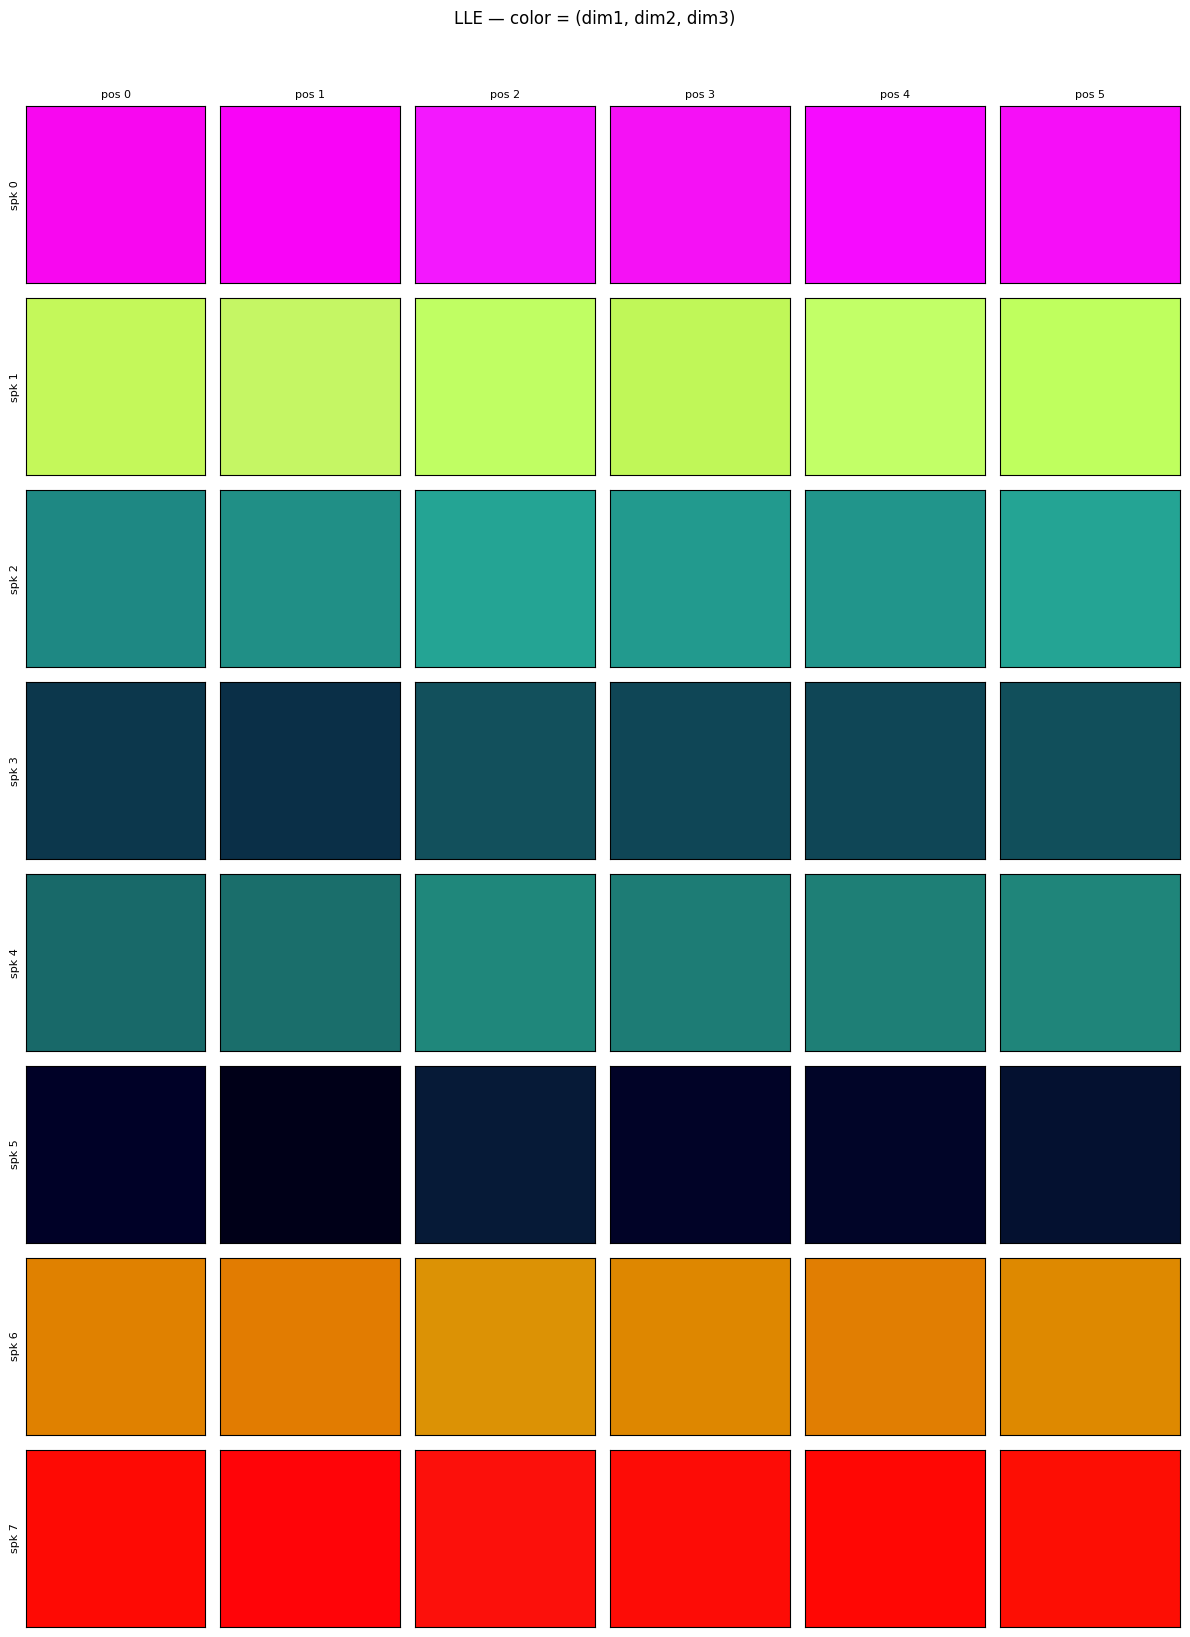

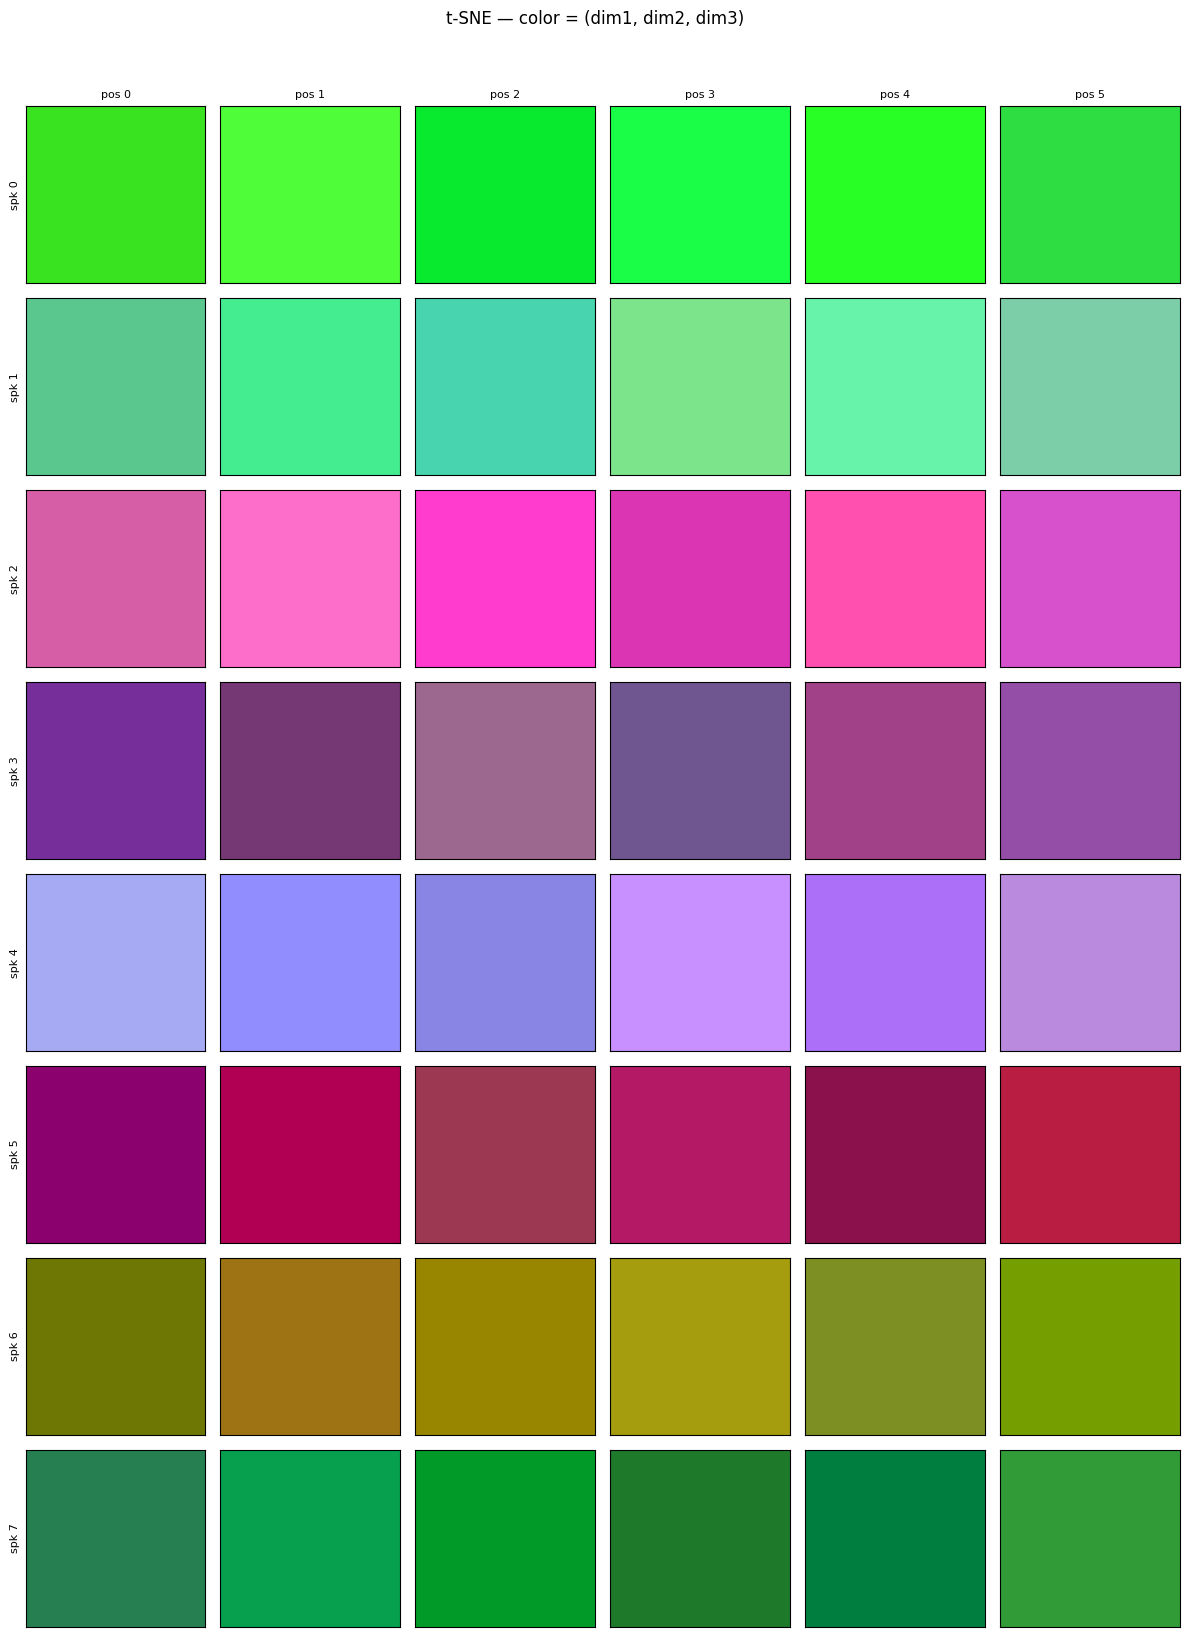

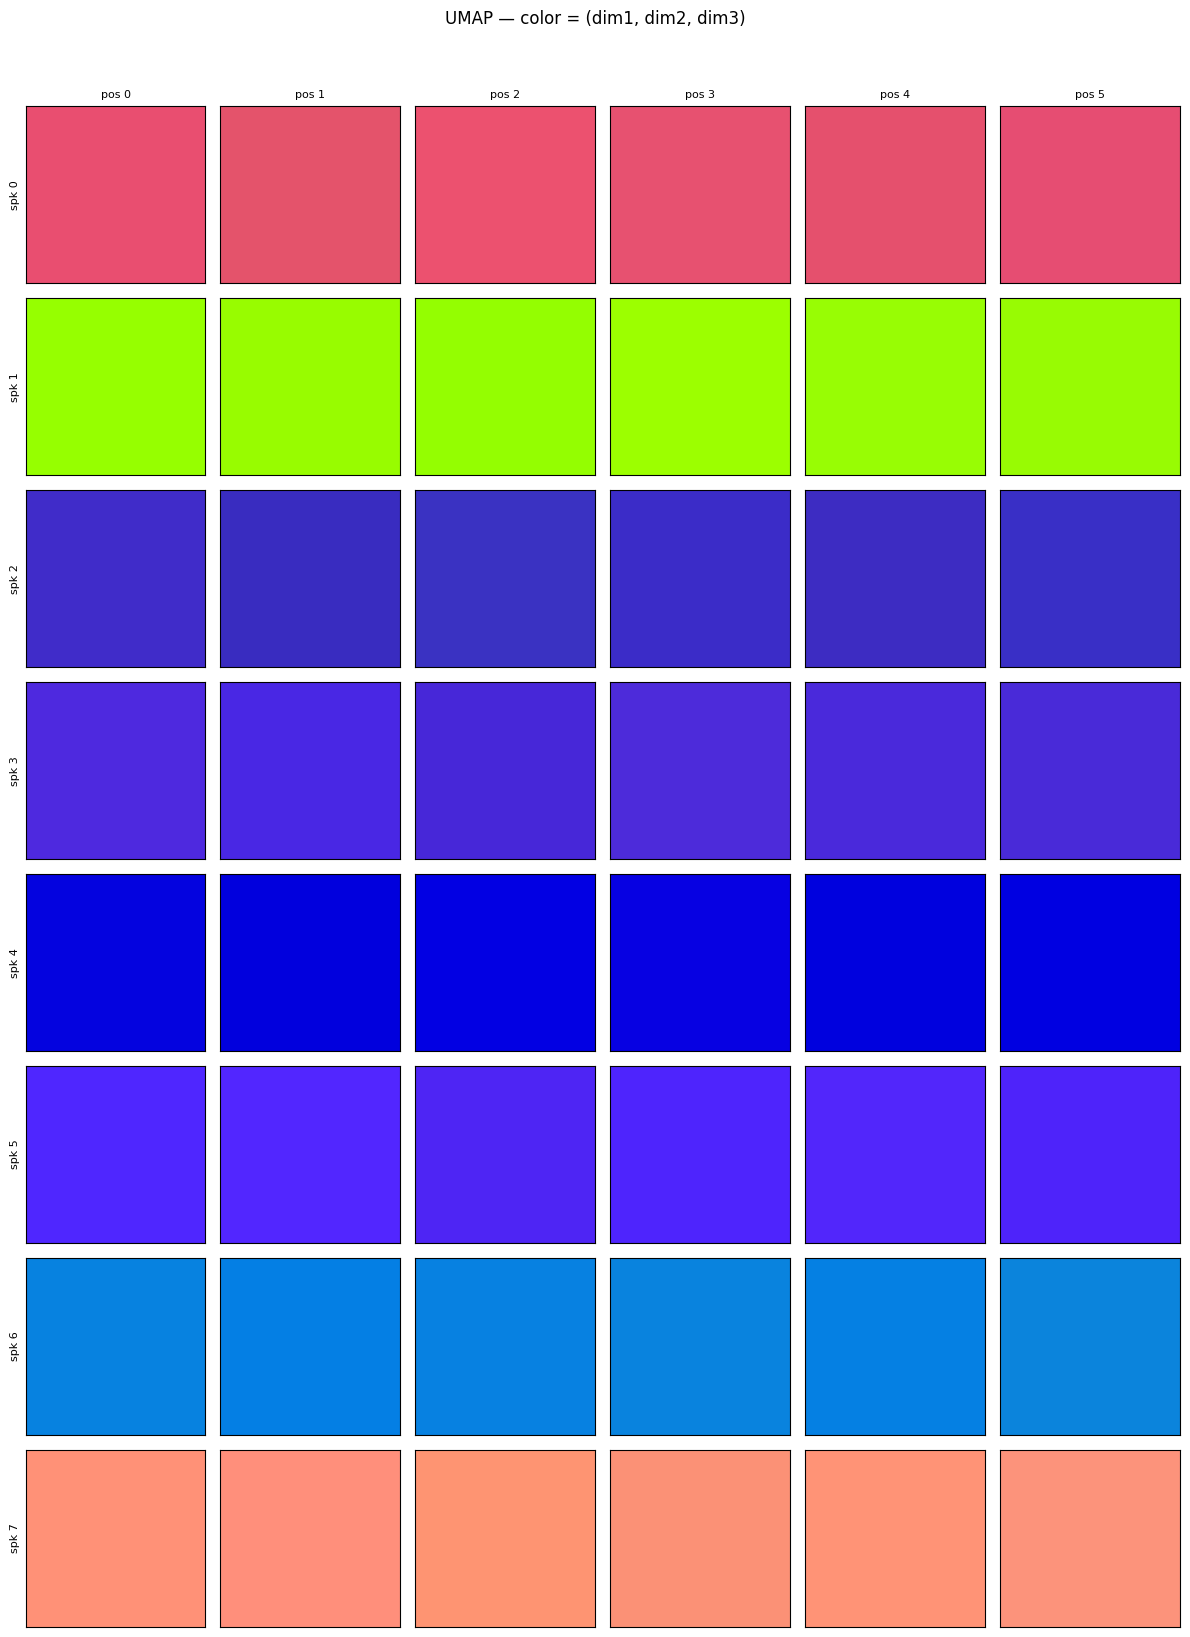

In [102]:
def plot_embedding_grid(embedding, title="", clip_pct=2):
    unique_pos = sorted(set(positions))
    unique_spk = sorted(set(speakers))

    def norm01(arr):
        lo, hi = np.percentile(arr, clip_pct), np.percentile(arr, 100 - clip_pct)
        return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)

    rgb_all = np.stack([norm01(embedding[:, i]) for i in range(3)], axis=1)

    cell = {}
    for i, (spk, pos) in enumerate(zip(speakers, positions)):
        cell[(spk, pos)] = rgb_all[i]

    fig, axes = plt.subplots(len(unique_spk), len(unique_pos),
                             figsize=(2 * len(unique_pos), 2 * len(unique_spk)), squeeze=False)
    for r, spk in enumerate(unique_spk):
        for c, pos in enumerate(unique_pos):
            ax = axes[r][c]
            color = cell.get((spk, pos))
            if color is not None:
                ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
            else:
                ax.set_facecolor("#eeeeee")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(f"pos {c}", fontsize=8)
            if c == 0:
                ax.set_ylabel(f"spk {spk}", fontsize=8)

    fig.suptitle(f"{title} — color = (dim1, dim2, dim3)", y=1.02)
    plt.tight_layout()
    plt.show()

for emb, name in [(pcs, "PCA"), (lle, "LLE"), (tsne, "t-SNE"), (ump, "UMAP")]:
    plot_embedding_grid(emb, title=name)
